In [1]:
import sys
sys.path.append('../src/training-on-CM2.6')
sys.path.append('../src/tensor_calculus')
import xarray as xr
import xgcm

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*Dataset.dims.*"
)

from helpers.plot_helpers import *
from helpers.selectors import *
from tensor_calculus import Tensor

%load_ext autoreload
%autoreload 3

In [2]:
def read_dataset(key='train'):
    base_path = '/scratch/zanna/data/cm2.6-Perezhogin-etal-2025/factor-4'
    
    # Read file with grid information
    depth_selector = lambda x: x.isel(zl=np.arange(0,50,5)) if len(x.zl)==50 else x
    static = depth_selector(xr.open_dataset(f'{base_path}/param.nc'))
    
    # Read permanent features
    permanent_features = xr.open_dataset(f'{base_path}/permanent_features.nc').load()
    
    # Read time-dependent data
    data = xr.open_mfdataset(f'{base_path}/{key}*.nc', chunks={'time':1}, concat_dim='time', combine='nested').sortby('time')

    # Merge permanent and time-depending datasets
    data = xr.merge([data, permanent_features])

    # xgcm grid
    grid = xgcm.Grid(static, coords={
                'X': {'center': 'xh', 'right': 'xq'},
                'Y': {'center': 'yh', 'right': 'yq'}
            },
            boundary={"X": 'periodic', 'Y': 'fill'},
            fill_value = {'Y':0})

    return data.astype('float64'), static.astype('float64'), grid

data, param, grid = read_dataset()

In [3]:
derivatives = {}
derivatives['D0'] = Tensor.init_vector(data.u_h, data.v_h, label="u_i")
derivatives['D1'] = derivatives['D0'].diff(param, grid)
derivatives['D2'] = derivatives['D1'].diff(param, grid)
derivatives['D3'] = derivatives['D2'].diff(param, grid)
derivatives['D4'] = derivatives['D3'].diff(param, grid)

# Manually set symmetric tensors

In [4]:
derivatives['D2'].set_symmetric_indices(['j','k'])
derivatives['D3'].set_symmetric_indices(['j','k', 'm'])
derivatives['D4'].set_symmetric_indices(['j','k', 'm', 'n'])

In [59]:
array = (derivatives['D1']*derivatives['D2']).contract_to_rank_one()[0].array.isel(zl=0,time=0,i=0).compute()

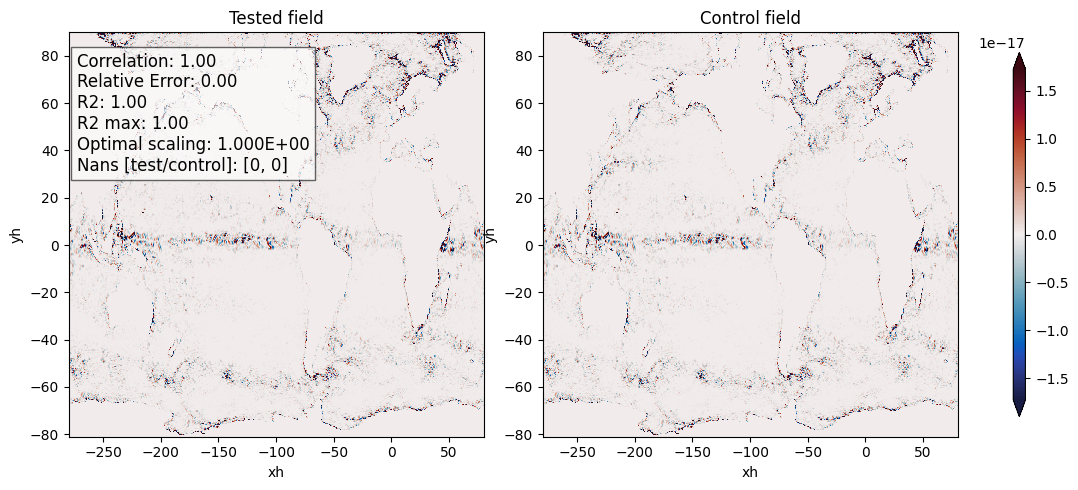

In [60]:
compare(array.astype('float32').astype('float64'), array.astype('float64'), selector=select_globe);

# Strain rate

In [30]:
strain_rate = (derivatives['D1'] + derivatives['D1'].transpose(['i', 'j']))
strain = (strain_rate * strain_rate).contract(['m', 'j']).contract(['i', 'k'])

strain

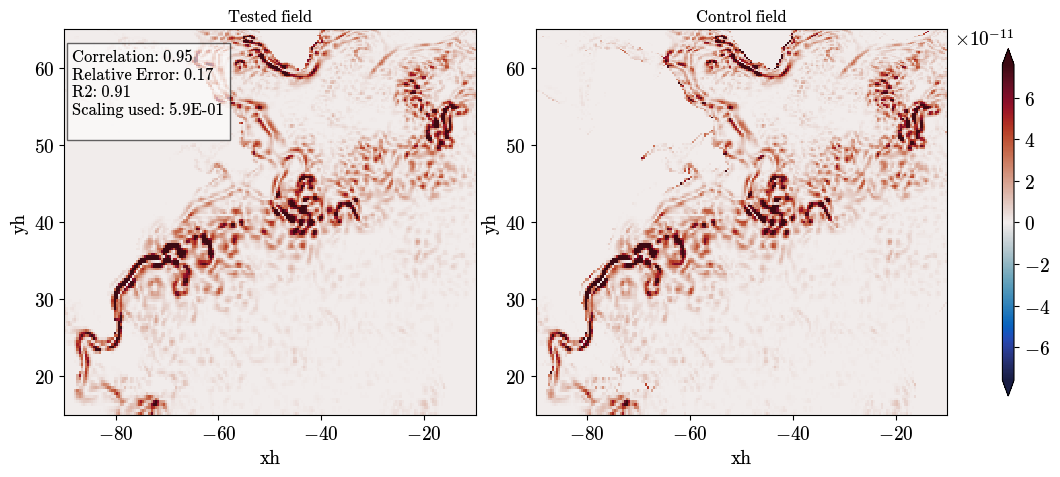

In [31]:
compare(strain.array[0][0], data.shear_mag[0][0]**2, scale=True);

# Set of all possible gradient models of second order

In [5]:
tensor_D1_D2 =  derivatives['D2'] * derivatives['D1']
NGM2_set = tensor_D1_D2.contract_to_rank_one()
len(NGM2_set)

9

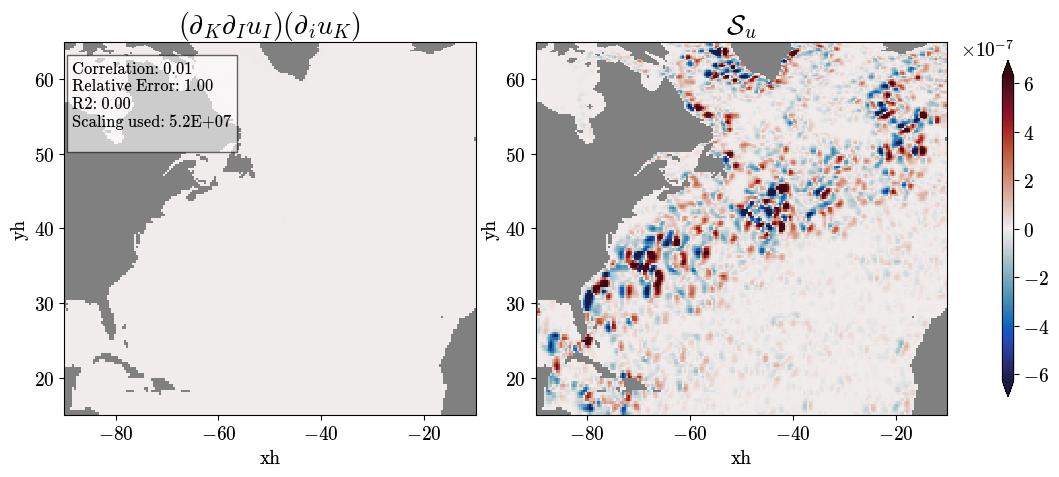

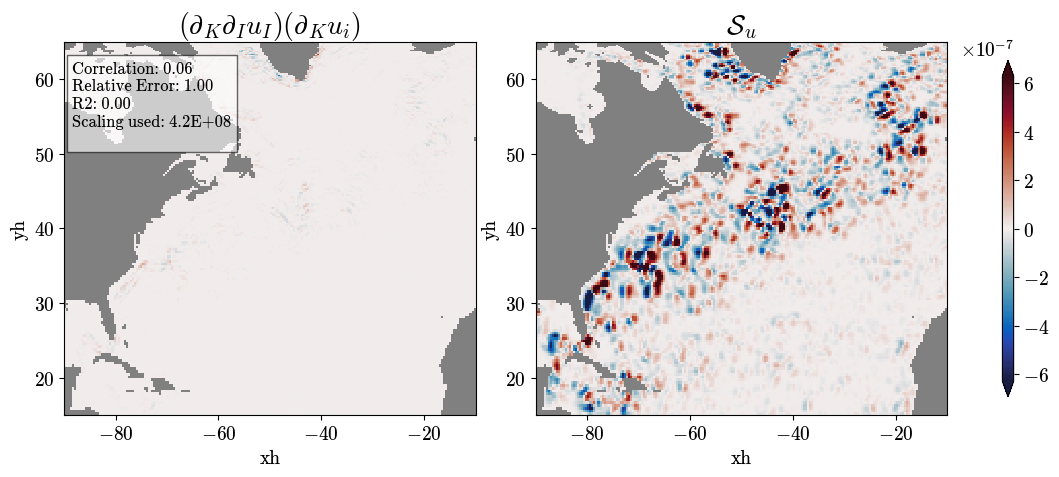

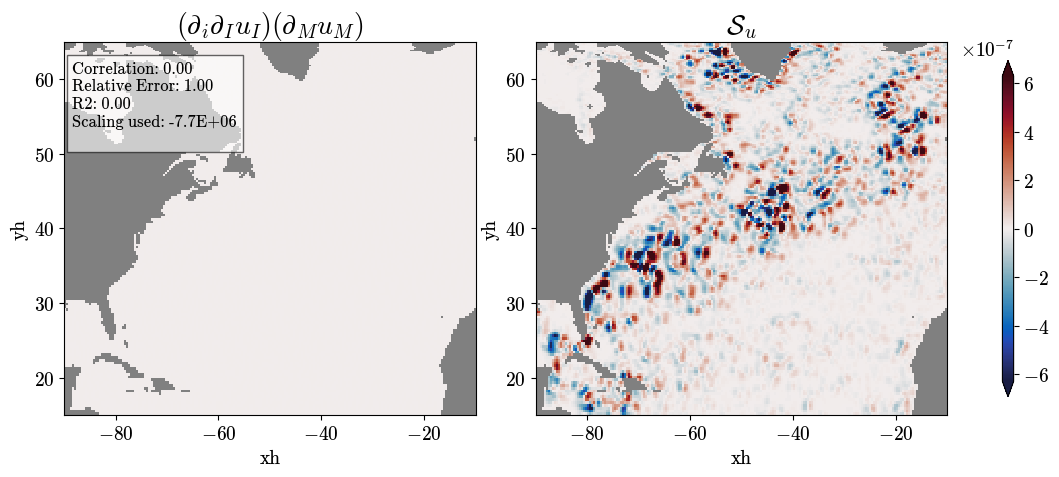

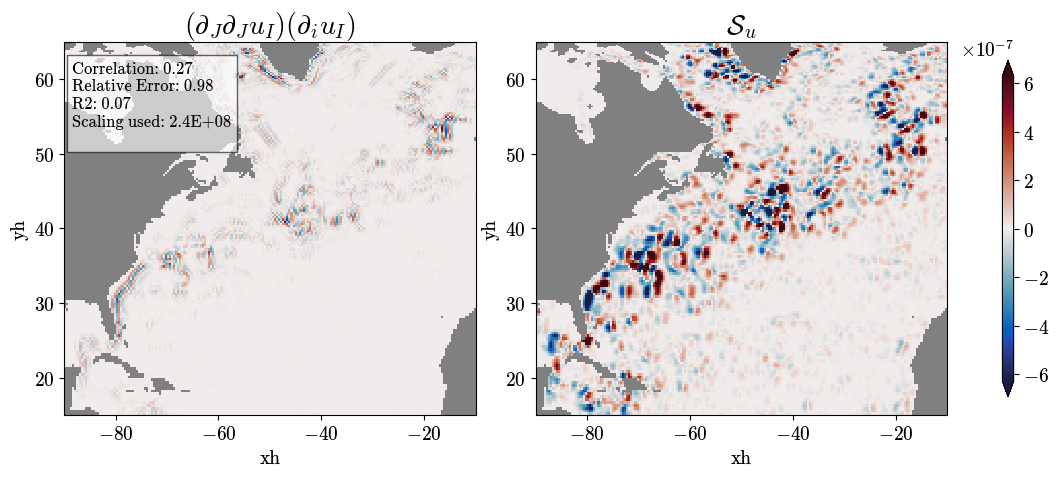

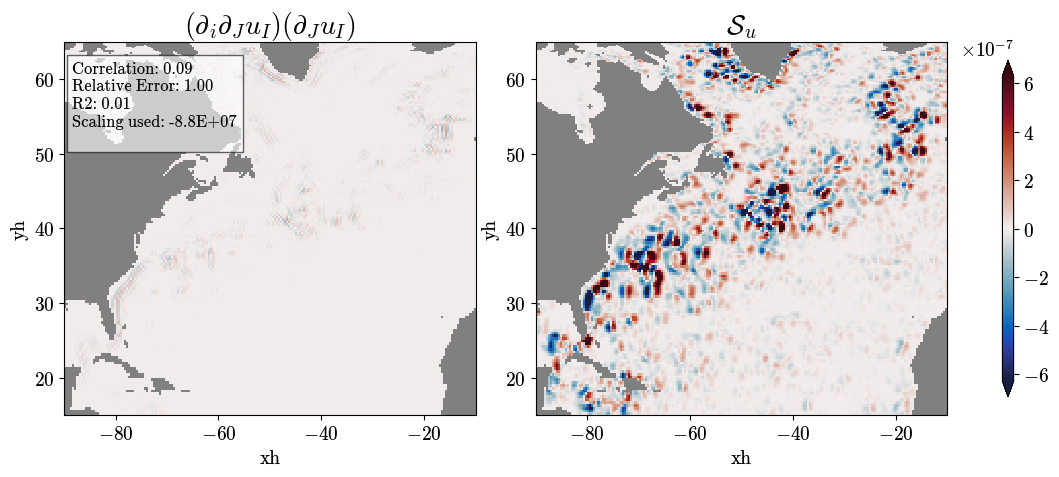

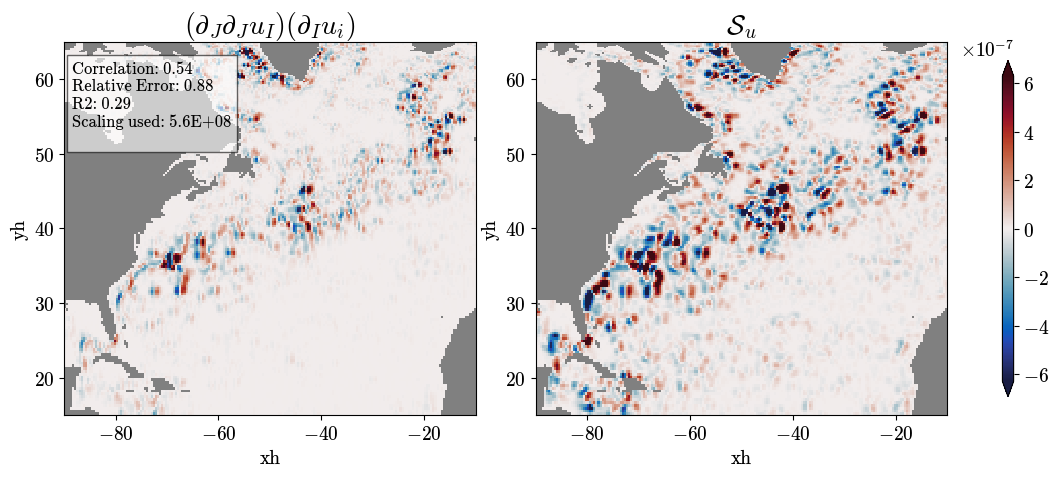

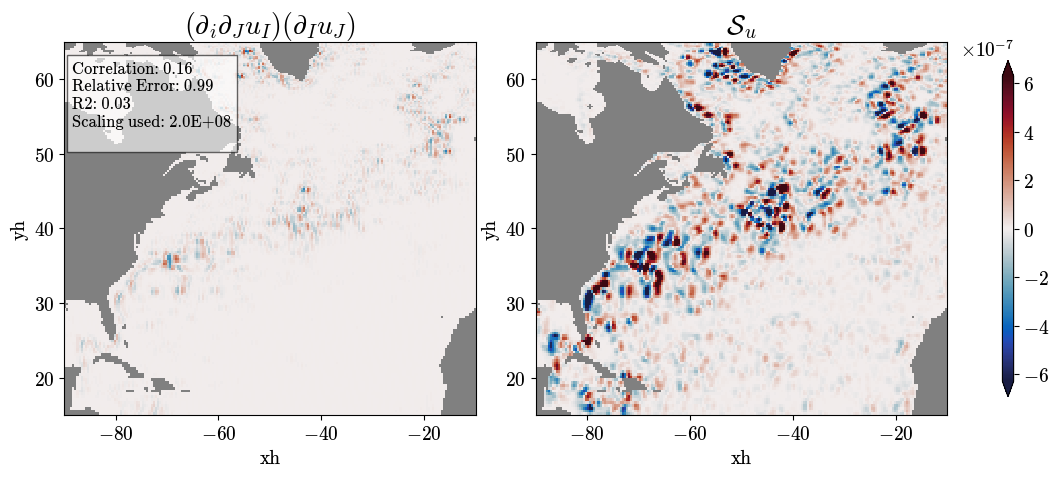

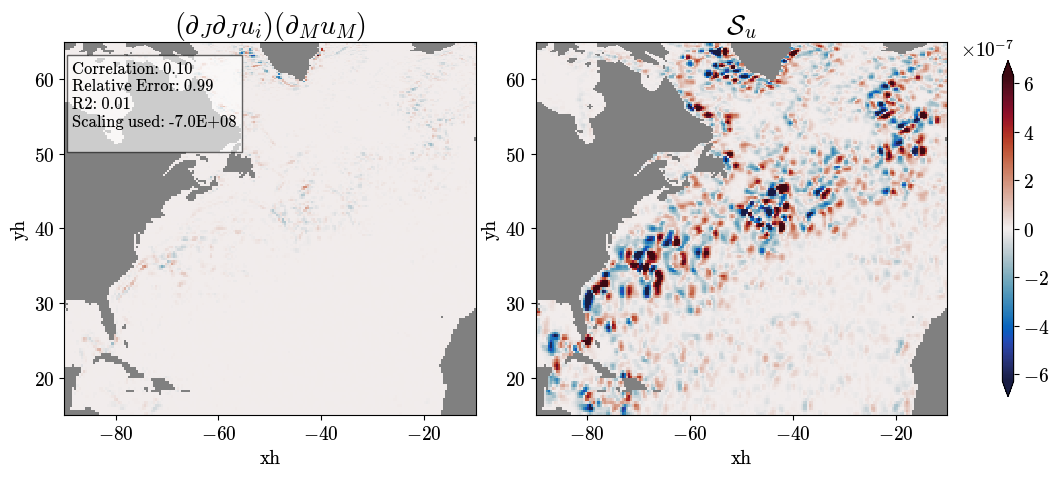

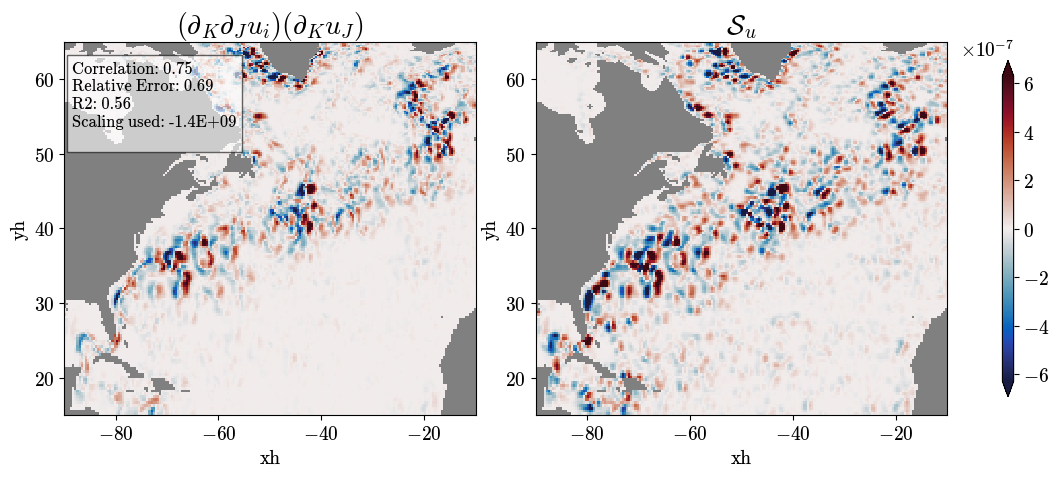

In [34]:
default_rcParams({'font.size':14})
mask = data.wet_nan[0]
for NGM2 in NGM2_set:
    compare(mask * NGM2.array[0][0].isel(i=0), mask * data.SGSx_h[0][0], scale=True, 
    label_control='$\\mathcal{S}_u$',
    label_test=NGM2._repr_latex_(), 
    fontsize=20)

# Construct basis up to a level of derivatives and level of nonlinearity

In [25]:
from IPython.display import Math, display
from itertools import combinations_with_replacement

def print_basis(results):
    print('Library of tensors has length', len(results))
    for t in results:
        display(Math(f"{t.rename()._repr_latex_()}"))

def construct_basis_of_tensors(derivatives, max_derivative=2, max_nonlinearity = 1,
                               max_total_derivative=6):
    results = []

    if max_nonlinearity >= 1:
        for d1 in range(0, max_derivative+1):
            if (d1 > max_total_derivative):
                continue
            high_rank_tensor = derivatives[f'D{d1}']
            results.extend(high_rank_tensor.contract_to_rank_one())

    if max_nonlinearity >= 2:
        for d1, d2 in combinations_with_replacement(range(0, max_derivative+1), 2):
            if (d1 + d2 > max_total_derivative):
                continue
            high_rank_tensor = derivatives[f'D{d1}']*derivatives[f'D{d2}']
            results.extend(high_rank_tensor.contract_to_rank_one())

    if max_nonlinearity >= 3:
        for d1, d2, d3 in combinations_with_replacement(range(0, max_derivative+1), 3):
            if (d1 + d2 + d3> max_total_derivative):
                continue
            high_rank_tensor = derivatives[f'D{d1}']*derivatives[f'D{d2}']*derivatives[f'D{d3}']
            results.extend(high_rank_tensor.contract_to_rank_one())

    if max_nonlinearity >= 4:
        for d1, d2, d3, d4 in combinations_with_replacement(range(0, max_derivative+1), 4):
            if (d1 + d2 + d3 + d4> max_total_derivative):
                continue
            high_rank_tensor = derivatives[f'D{d1}']*derivatives[f'D{d2}']*derivatives[f'D{d3}']*derivatives[f'D{d4}']
            results.extend(high_rank_tensor.contract_to_rank_one())
    return results

In [26]:
basis = construct_basis_of_tensors(derivatives, max_derivative=4)
print_basis(basis)

Library of tensors has length 5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [28]:
basis = construct_basis_of_tensors(derivatives, max_derivative=2, max_nonlinearity=2, max_total_derivative=2)
print_basis(basis)

Library of tensors has length 6


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [89]:
basis = construct_basis_of_tensors(derivatives, max_derivative=2, max_nonlinearity=3, max_total_derivative=6)
print_basis(basis)

Library of tensors has length 121


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [67]:
basis[40]

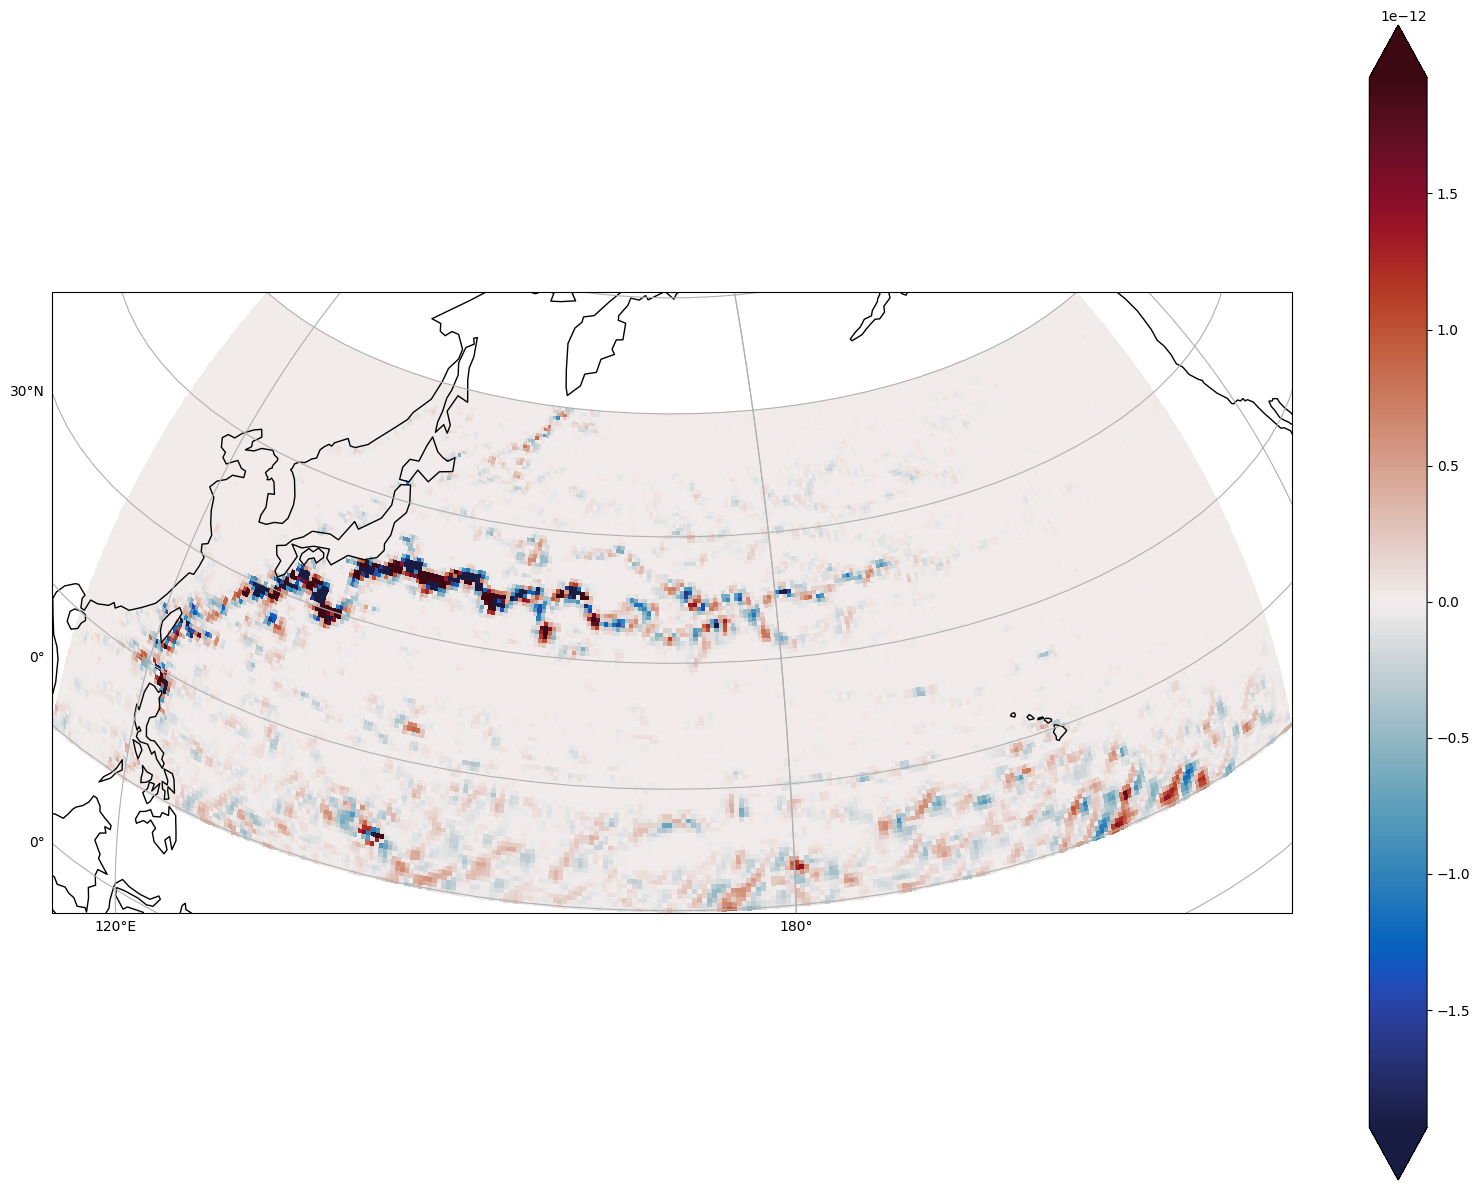

In [66]:
plot(basis[40].array.isel(time=0,zl=0,i=0).sel(yh=slice(10,50)), selector=select_Pacific)

In [24]:
len(["i", "j", "k", "m", "n", "l", "o", "s", "t", "p", "q", "r", "a", "b"])

14

In [110]:
basis = construct_basis_of_tensors(derivatives, max_derivative=4, max_nonlinearity=2)
#print_basis(basis)

/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(
/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


# Save basis in a separate file for discovery

In [223]:
from tensor_calculus import transposition_data
SGS = transposition_data(xr.concat([data.SGSx_h, data.SGSy_h], dim='i'))
selector = lambda x: x.isel(time=[0,-1])

In [224]:
wet_nan = data.wet_nan
def filter_n(array, n=1):
    for i in range(n):
        array = grid.interp(array, ['X', 'Y'])
    return array

wet_nan10 = filter_n(wet_nan, 10)

In [225]:
dataset = xr.Dataset()
dataset['wet_nan'] = (wet_nan).compute()
dataset['wet_nan10'] = (wet_nan10).compute()
dataset['SGS'] = selector(SGS).compute()
dataset['SGS'].attrs["long_name"] = r"$\mathcal{S}$"

V = transposition_data(xr.concat([data.u_h, data.v_h], dim='i'))
dataset['V'] = selector(V).compute()
dataset['V'].attrs["long_name"] = '$u_i$'

In [235]:
for j, tensor in enumerate(basis):
    dataset[f'{j}'] = selector(tensor.array).compute()
    dataset[f'{j}'].attrs["long_name"] = tensor._repr_latex_()
    print(j)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42


: 

In [211]:
dataset.astype('float32').to_netcdf('equation-discovery/D4_quadratic.nc')

# Sequential regression

In [3]:
#ds = xr.open_dataset('/scratch/pp2681/mom6/equation-discovery/global_D4_quadratic.nc')
#set_of_features=[f'{i}' for i in range(70)]
ds = xr.open_dataset('/scratch/pp2681/mom6/equation-discovery/Pacific_D2_DD6_NN3.nc')
set_of_features=[f'{i}' for i in range(121)]

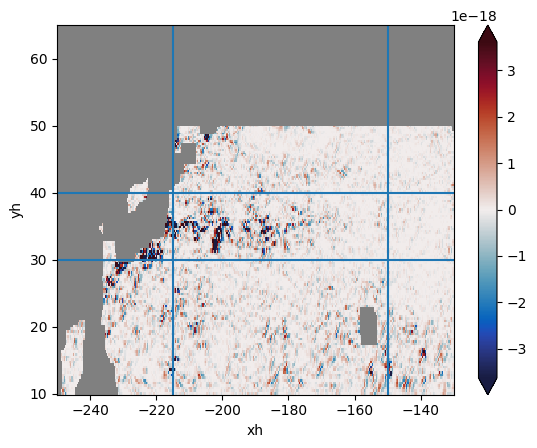

In [4]:
plot(ds.wet_nan10*ds['6'], selector=select_Pacific, cartopy=False)
plt.axhline(y=30)
plt.axhline(y=40)
plt.axvline(x=-215)
plt.axvline(x=-150)

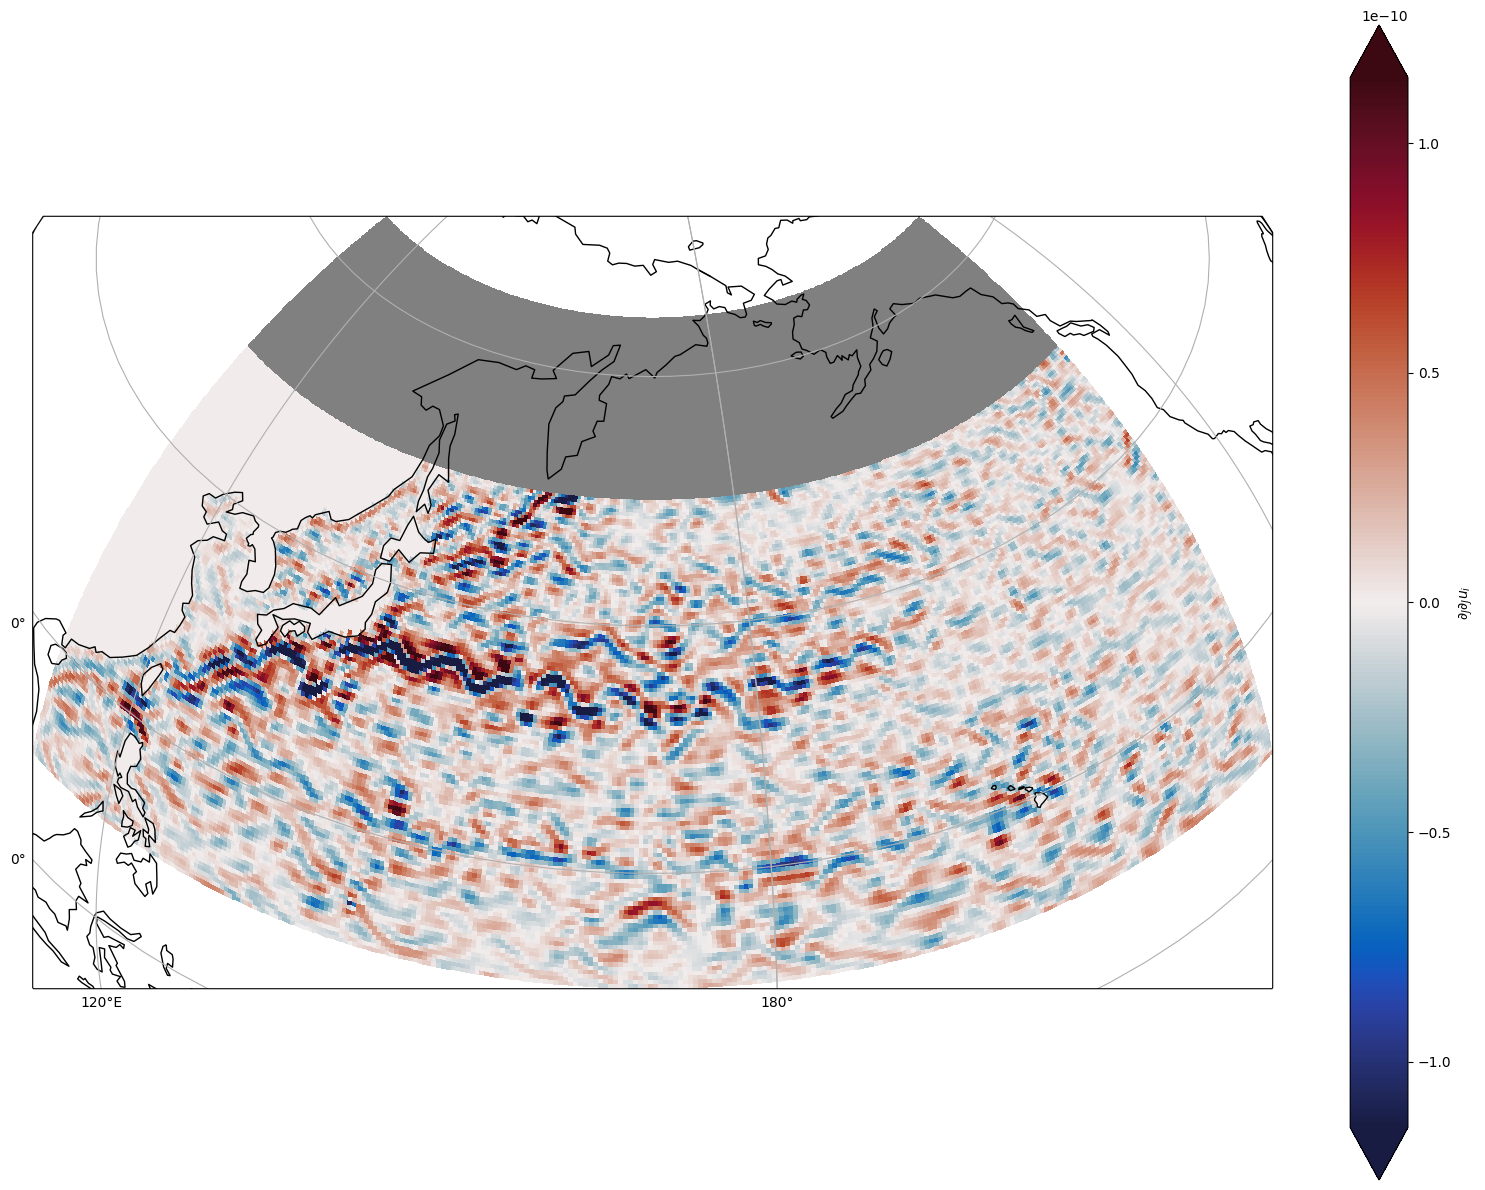

In [5]:
plot(ds['2'], selector=select_Pacific)

In [6]:
def corr(x,y):
    '''
    Not centered correlation as we do not have intercept
    in our linear model
    '''
    return float((x*y).mean() / np.sqrt((x**2).mean() * (y**2).mean()))

In [23]:
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.preprocessing import StandardScaler
from IPython.display import Math, display


NA = lambda x: x.sel(xh=slice(-50,-20), yh=slice(30,50))
Pacific = lambda x: x.sel(xh=slice(-215,-150), yh=slice(30,40))

def sequential_regression(dataset,
    set_of_features=None, 
    fetch_train = lambda ds, key: Pacific(ds[key]).isel(time=range(0,20)),
    fetch_test  = lambda ds, key: Pacific(ds[key]).isel(time=range(-20,0)),
    target_key = 'SGS',
    num_iterations = 1,
    show_top=1,
    max_derivative = 1,
    ):

    target = fetch_train(dataset, target_key)
    target_test = fetch_test(dataset, target_key)
    selected_features = []
    residual = target.copy()
    for iteration in range(num_iterations):
        # Compute correlation with residuals
        corrs = []
        for key in set_of_features:
            if dataset[key].long_name.count('\partial') <= max_derivative:
                feature = fetch_train(dataset, key).copy()
                feature_test = fetch_test(dataset, key).copy()
                corrs.append((key, feature, feature_test, np.abs(corr(feature, residual))))
        
        # Print top 5 correlations
        corrs.sort(key = lambda x: x[3], reverse=True)
        for i in range(min(show_top, len(corrs))):
            key, feature, feature_test, correlation = corrs[i]
            display(Math(dataset[key].long_name+f' correlation of tensor {key} with residual: ${correlation:.2f}$'))

        if (len(corrs) == 0):
            return
        # Select best feature
        selected_features.append((corrs[0][:3]))

        # Regression for a set of current features
        y = target.values.reshape(-1,1)
        y_test = target_test.values.reshape(-1,1)
        x = np.array([xx[1].values.reshape(-1) for xx in selected_features]).T
        x_test = np.array([xx[2].values.reshape(-1) for xx in selected_features]).T

        # Scaling features
        scaler_x = StandardScaler(with_mean=False)
        scaler_y = StandardScaler(with_mean=False)
        x_scaled = scaler_x.fit_transform(x)
        y_scaled = scaler_y.fit_transform(y)

        model = LinearRegression(fit_intercept=False)
        model.fit(x_scaled,y_scaled)

        y_pred = scaler_y.scale_ * model.predict(x_scaled)
        r2 = sklearn.metrics.r2_score(y, y_pred)

        x_test_scaled = scaler_x.transform(x_test)
        y_test_pred = scaler_y.scale_ * model.predict(x_test_scaled)
        r2_test = sklearn.metrics.r2_score(y_test, y_test_pred)
        
        print(f"Interation {iteration}: R squared [train/test]: [{r2:.4f},{r2_test:.4f}]")

        # Remove already used feature
        set_of_features.remove(corrs[0][0])
        # Update residual
        residual = target.copy() - y_pred.reshape(target.shape)

        print()
        

In [24]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=3, max_derivative = 6)

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.7719,0.7594]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7911,0.7776]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7960,0.7828]



In [31]:
import copy
set_of_features_filtered = copy.deepcopy(set_of_features)
set_of_features_filtered.remove('9')
set_of_features_filtered.remove('0')
sequential_regression(ds, set_of_features=set_of_features_filtered,
                      num_iterations=3, max_derivative = 6)

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.3508,0.3463]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7616,0.7513]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7854,0.7701]



In [12]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.8884,0.8537]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.8989,0.8697]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.9076,0.8805]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.9124,0.8905]



<IPython.core.display.Math object>

Interation 4: R squared [train/test]: [0.9137,0.8922]



In [13]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.7614,0.7422]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.7851,0.7729]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.7975,0.7814]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.8016,0.7835]



<IPython.core.display.Math object>

Interation 4: R squared [train/test]: [0.8048,0.7858]



In [14]:
import copy
sequential_regression(ds, set_of_features=copy.deepcopy(set_of_features),
                      num_iterations=5, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.8079,0.7371]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.8837,0.8010]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.8965,0.8398]



KeyboardInterrupt: 

In [ ]:
set_of_features_filtered = copy.deepcopy(set_of_features)
set_of_features_filtered.remove('9')
set_of_features_filtered.remove('0')
set_of_features_filtered.remove('3')
set_of_features_filtered.remove('30')
set_of_features_filtered.remove('6')
sequential_regression(ds, set_of_features=set_of_features_filtered,
                      num_iterations=10, max_derivative = 6,
                      fetch_train = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(0,20)).mean('time'),
                      fetch_test  = lambda ds, key: Pacific(ds[key]*ds.V).isel(time=range(-20,0)).mean('time'),
                      )

<IPython.core.display.Math object>

Interation 0: R squared [train/test]: [0.5011,0.4957]



<IPython.core.display.Math object>

Interation 1: R squared [train/test]: [0.6096,0.5653]



<IPython.core.display.Math object>

Interation 2: R squared [train/test]: [0.6860,0.6327]



<IPython.core.display.Math object>

Interation 3: R squared [train/test]: [0.7149,0.6312]



KeyboardInterrupt: 